## Q4

In [35]:
# ============================================================
# Q4: MNIST Classification with Multiple Models
# ============================================================
import os
import os
os.chdir(r'D:\HKUST\5054_Statistical_Machine_Learning\Final')

import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt

# sklearn models and utilities
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# torch for CNN
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# ============================================================
# Set random seeds for reproducibility
# ============================================================

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

# ============================================================
# Load MNIST CSV data
# ============================================================

train_df = pd.read_csv("train_MNIST.csv")
test_df = pd.read_csv("test_MNIST.csv")

y_train = train_df.iloc[:, 0].values
X_train = train_df.iloc[:, 1:].values

y_test = test_df.iloc[:, 0].values
X_test = test_df.iloc[:, 1:].values

# ============================================================
# Standardize features (for non-CNN models)
# ============================================================

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ============================================================
# (a) Logistic Regression
# ============================================================

# Multinomial logistic regression (softmax)
log_reg = LogisticRegression(
    multi_class="multinomial",
    solver="lbfgs",
    max_iter=1000,
    C=1.0,
    n_jobs=-1,
    random_state=SEED
)

log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)

lr_test_error = 1 - accuracy_score(y_test, y_pred_lr)
print(f"(a) Logistic Regression Test Error: {lr_test_error:.4f}")



d:\users\anaconda3\envs\ZeroGen\lib\site-packages\sklearn\linear_model\_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


(a) Logistic Regression Test Error: 0.1271


In [38]:
# ============================================================
# (b) Boosting Tree Classifier (Gradient Boosting)
# ============================================================

# Note: This can be slow on MNIST
gb_clf = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=SEED
)

gb_clf.fit(X_train_scaled, y_train)
y_pred_gb = gb_clf.predict(X_test_scaled)

gb_test_error = 1 - accuracy_score(y_test, y_pred_gb)
print(f"(b) Boosting Tree Test Error: {gb_test_error:.4f}")

(b) Boosting Tree Test Error: 0.1371


In [6]:
# ============================================================
# (c) Support Vector Machine (SVM)
# ============================================================

# RBF kernel SVM (very strong but slow)
svm_clf = SVC(
    kernel="rbf",
    C=5.0,
    gamma="scale",
    random_state=SEED
)

svm_clf.fit(X_train_scaled, y_train)
y_pred_svm = svm_clf.predict(X_test_scaled)

svm_test_error = 1 - accuracy_score(y_test, y_pred_svm)
print(f"(c) SVM Test Error: {svm_test_error:.4f}")

(c) SVM Test Error: 0.1171


In [30]:
# ============================================================
# (d) CNN
# ============================================================

print(X_train.shape)
print("Unique labels:", np.unique(y_train))

X_train_cnn = X_train.reshape(-1, 1, 14, 14) / 255.0
X_test_cnn = X_test.reshape(-1, 1, 14, 14) / 255.0

X_train_tensor = torch.tensor(X_train_cnn, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_test_tensor = torch.tensor(X_test_cnn, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# ------------------------------------------------------------
# CNN: only ONE pooling layer
# ------------------------------------------------------------
class CNN14(nn.Module):
    def __init__(self):
        super(CNN14, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),  # 14x14
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2)                              # 7x7
        )

        self.classifier = nn.Sequential(
            nn.Linear(32 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN14().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# ------------------------------------------------------------
# Train
# ------------------------------------------------------------
EPOCHS = 20
model.train()
for epoch in range(EPOCHS):
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()

# ------------------------------------------------------------
# Evaluate
# ------------------------------------------------------------
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        preds = model(xb).argmax(dim=1)
        total += yb.size(0)
        correct += (preds == yb).sum().item()

cnn_test_error = 1 - correct / total
print(f"(d) CNN Test Error: {cnn_test_error:.4f}")


(699, 196)
Unique labels: [0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]
(d) CNN Test Error: 0.2341


In [9]:
# ============================================================
# (e) Additional Method: Random Forest
# ============================================================

rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    n_jobs=-1,
    random_state=SEED
)

rf_clf.fit(X_train_scaled, y_train)
y_pred_rf = rf_clf.predict(X_test_scaled)

rf_test_error = 1 - accuracy_score(y_test, y_pred_rf)
print(f"(e) Random Forest Test Error: {rf_test_error:.4f}")

(e) Random Forest Test Error: 0.0936


# Q5

(a) PCA Fisher Ratio: 0.0520


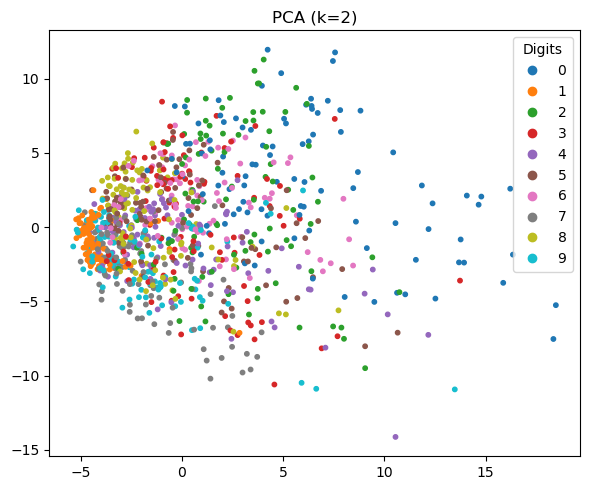

In [61]:
# ============================================================
# Q5: Dimension Reduction on MNIST-DR (14x14)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, Isomap
from sklearn.metrics import pairwise_distances

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# ============================================================
# Reproducibility
# ============================================================

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

# ============================================================
# Load data
# ============================================================

df = pd.read_csv("MNIST-DR.csv")

y = df.iloc[:, 0].values.astype(int)
X = df.iloc[:, 1:].values

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ============================================================
# Fisher Discriminant Ratio
# ============================================================

def fisher_ratio(Z, y):
    classes = np.unique(y)
    means = {c: Z[y == c].mean(axis=0) for c in classes}

    # Between-class separation
    sep = 0.0
    for i in classes:
        for j in classes:
            if i < j:
                sep += np.linalg.norm(means[i] - means[j]) ** 2

    # Within-class spread
    spread = 0.0
    for c in classes:
        spread += ((Z[y == c] - means[c]) ** 2).sum()

    return sep / spread

# ============================================================
# Helper: visualization
# ============================================================

def plot_embedding(Z, y, title):
    plt.figure(figsize=(6, 5))
    scatter = plt.scatter(Z[:, 0], Z[:, 1], c=y, cmap="tab10", s=10)
    plt.legend(*scatter.legend_elements(), title="Digits")
    plt.title(title)
    plt.tight_layout()
    plt.show()

# ============================================================
# (a) PCA (k=2)
# ============================================================

pca = PCA(n_components=2, whiten=False, random_state=SEED) 
Z_pca = pca.fit_transform(X_scaled) 
pca_fisher = fisher_ratio(Z_pca, y) 
print(f"(a) PCA Fisher Ratio: {pca_fisher:.4f}") 
plot_embedding(Z_pca, y, "PCA (k=2)")



(b) t-SNE Fisher Ratio: 0.2620


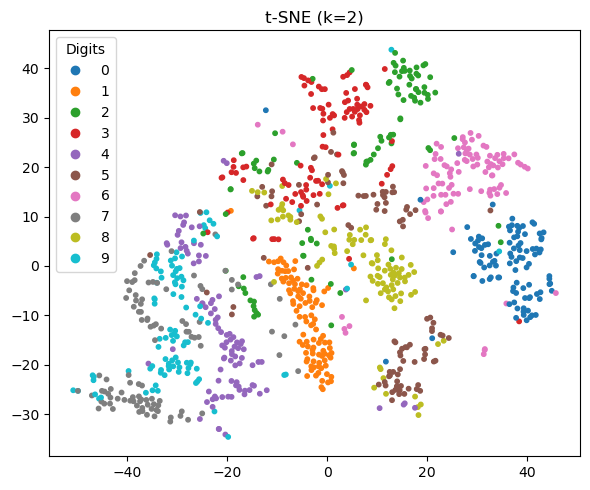

In [62]:
# ============================================================
# (b) t-SNE (k=2)
# ============================================================

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    n_iter_without_progress = 300,
    random_state=SEED,
)

Z_tsne = tsne.fit_transform(X_scaled)

tsne_fisher = fisher_ratio(Z_tsne, y)
print(f"(b) t-SNE Fisher Ratio: {tsne_fisher:.4f}")
plot_embedding(Z_tsne, y, "t-SNE (k=2)")


(c) ISOMAP Fisher Ratio: 0.0600


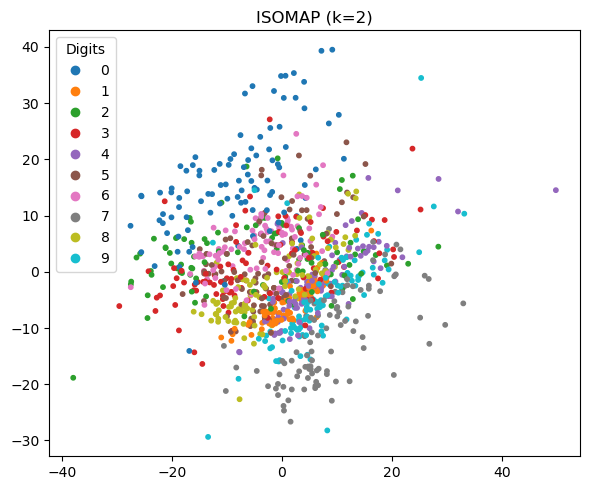

In [65]:
# ============================================================
# (c) ISOMAP (k=2)
# ============================================================

isomap = Isomap(
    n_neighbors=20,
    n_components=2
)

Z_iso = isomap.fit_transform(X_scaled)

iso_fisher = fisher_ratio(Z_iso, y)
print(f"(c) ISOMAP Fisher Ratio: {iso_fisher:.4f}")
plot_embedding(Z_iso, y, "ISOMAP (k=2)")

(d) VAE Fisher Ratio: 0.0788


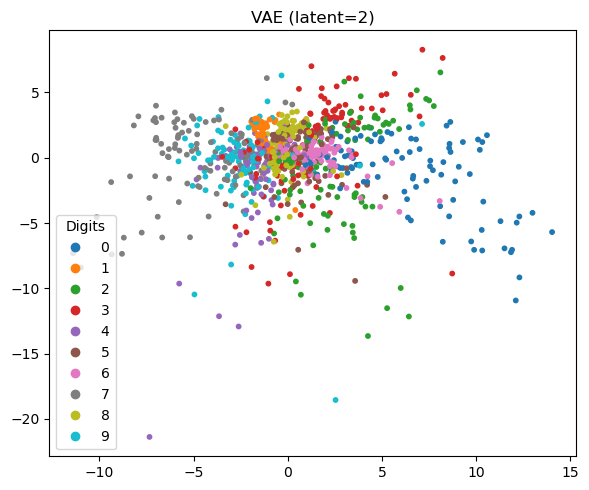

In [71]:
# ============================================================
# (d) Variational Autoencoder (VAE)
# ============================================================

class VAE(nn.Module):
    def __init__(self, input_dim=196, latent_dim=2):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.fc_mu = nn.Linear(128, latent_dim)
        self.fc_logvar = nn.Linear(128, latent_dim)
        self.fc2 = nn.Linear(latent_dim, 128)
        self.fc3 = nn.Linear(128, input_dim)

    def encode(self, x):
        h = torch.relu(self.fc1(x))
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = torch.relu(self.fc2(z))
        return self.fc3(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

def vae_loss(recon_x, x, mu, logvar, beta=0.1):
    recon = nn.functional.mse_loss(recon_x, x, reduction="sum")
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon + beta * kl

X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
y_tensor = torch.tensor(y)

loader = DataLoader(
    TensorDataset(X_tensor, y_tensor),
    batch_size=64,
    shuffle=True
)

vae = VAE()
optimizer = optim.Adam(vae.parameters(), lr=1e-3)

vae.train()
for epoch in range(30):
    for xb, _ in loader:
        optimizer.zero_grad()
        recon, mu, logvar = vae(xb)
        loss = vae_loss(recon, xb, mu, logvar, beta=0.1)
        loss.backward()
        optimizer.step()

vae.eval()
with torch.no_grad():
    _, Z_vae, _ = vae(X_tensor)

Z_vae = Z_vae.numpy()

vae_fisher = fisher_ratio(Z_vae, y)
print(f"(d) VAE Fisher Ratio: {vae_fisher:.4f}")
plot_embedding(Z_vae, y, "VAE (latent=2)")


(e) Spectral Embedding Fisher Ratio: 0.2602


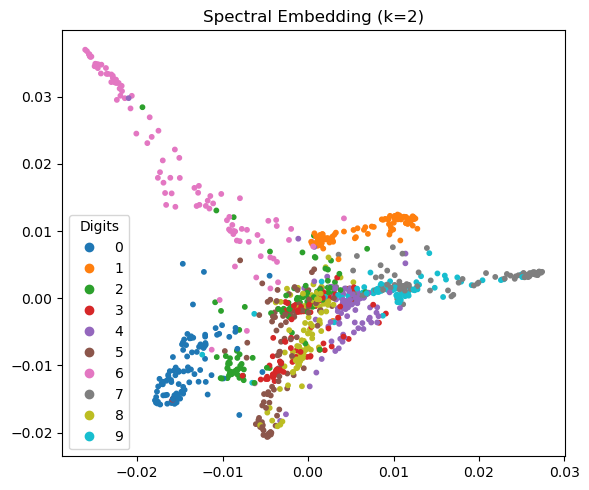

In [44]:
# ============================================================
# (e) Other Method: Spectral Embedding
# ============================================================

from sklearn.manifold import SpectralEmbedding

spec = SpectralEmbedding(
    n_components=2,
    n_neighbors=10,
    random_state=SEED
)

Z_spec = spec.fit_transform(X_scaled)

spec_fisher = fisher_ratio(Z_spec, y)
print(f"(e) Spectral Embedding Fisher Ratio: {spec_fisher:.4f}")
plot_embedding(Z_spec, y, "Spectral Embedding (k=2)")